# Problem Statement :
The objective of this project is to perform Exploratory Data Analysis (EDA) on a healthcare stroke dataset to identify patterns, trends, and relationships between various demographic and medical factors that influence stroke occurrence. The analysis focuses on data cleaning, visualization, handling missing values, detecting outliers, and generating insights that can assist in understanding stroke risk factors and support future predictive analytics.

## Import libraries 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'C:\Users\mones\Downloads\healthcare-dataset-stroke-data (1).csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df.shape

(5110, 12)

### Observation :
There are 5110 rows and 12 columns 

# Checking datatypes, null values and memory usage

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


#### Observations:
- Age varies widely
- Average glucose level has high variability
- BMI values are spread over a large range
- Ouliers may exist.

## Data Cleaning :
1. Missing values
2. Duplicates
3. Outliers
4. Type Casting
5. Noisy or inconsistent data

## Detecting noisy and null Values

In [7]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

<Axes: >

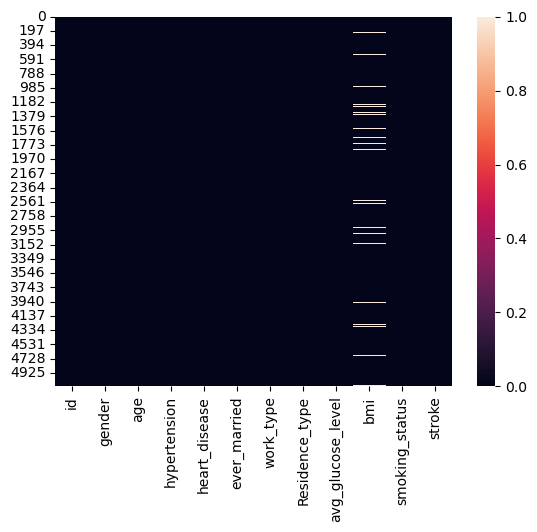

In [8]:
sns.heatmap(df.isnull())

In [9]:
round((df.isnull().sum()/df.shape[0]) * 100,2)

id                   0.00
gender               0.00
age                  0.00
hypertension         0.00
heart_disease        0.00
ever_married         0.00
work_type            0.00
Residence_type       0.00
avg_glucose_level    0.00
bmi                  3.93
smoking_status       0.00
stroke               0.00
dtype: float64

In [10]:
df[df['bmi'].isnull() == True]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5039,42007,Male,41.0,0,0,No,Private,Rural,70.15,NaN,formerly smoked,0
5048,28788,Male,40.0,0,0,Yes,Private,Urban,191.15,NaN,smokes,0
5093,32235,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,NaN,smokes,0
5099,7293,Male,40.0,0,0,Yes,Private,Rural,83.94,NaN,smokes,0


#### Handiling Missing vlaues

In [11]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [12]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

### Detecting and Handliling duplicates

In [13]:
df.duplicated().sum()

np.int64(0)

#### Observation :
There are no duplicate values in the dataset

### Checking Unique Values

In [14]:
df.nunique()

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

#### Observation :
- ID is unique for each patient
- Stroke has only two classes:
  > - 0
  > - 1


In [15]:
df.smoking_status.value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [16]:
df.smoking_status.value_counts(normalize = True)

smoking_status
never smoked       0.370254
Unknown            0.302153
formerly smoked    0.173190
smokes             0.154403
Name: proportion, dtype: float64

`Note` :- There are 1544 or 30.2% of 'Unknown' smoking_status This column is left as it is.

In [17]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

#### Observation :
- Majority belong to class 0 (No Stroke)
- Very few belong to class 1 (Stroke)
- Dataset is highly imbalanced

#### Remove ID Column

In [18]:
df.drop('id',axis=1,inplace=True)

#### Observation:
ID has no predictive values. so Removing id improves analysis.

# Detecting and Handling Outliers :

In [19]:
num_df = df.select_dtypes(include = 'number')
num_df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,67.0,0,1,228.69,36.6,1
1,61.0,0,0,202.21,28.1,1
2,80.0,0,1,105.92,32.5,1
3,49.0,0,0,171.23,34.4,1
4,79.0,1,0,174.12,24.0,1


In [20]:
num_df.skew()

age                 -0.137059
hypertension         2.715392
heart_disease        3.947244
avg_glucose_level    1.572284
bmi                  1.088187
stroke               4.193284
dtype: float64

In [21]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,28.1,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [22]:
df = df[(df['bmi'] > 10) & (df['bmi'] < 60)]
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,28.1,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


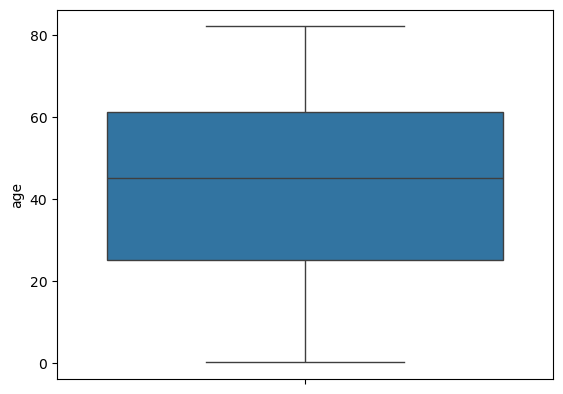

In [23]:
sns.boxplot(df['age'])
plt.show()

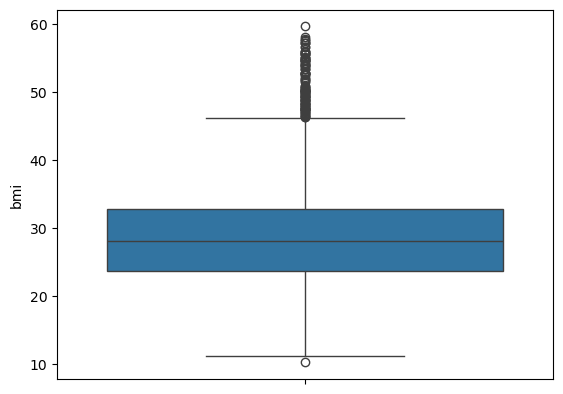

In [24]:
sns.boxplot(df['bmi'])
plt.show()

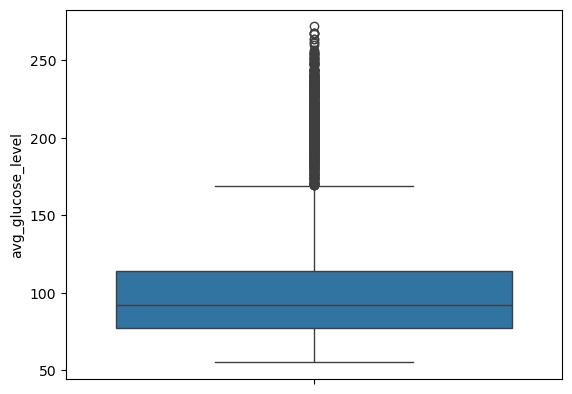

In [25]:
sns.boxplot(df['avg_glucose_level'])
plt.show()

#### Explaination :
We did not remove outliers because hypertension, heart_disease, and stroke are binary variables with valid values (0 and 1), so outlier detection is not applicable. For avg_glucose_level and bmi, the extreme values may represent genuine medical conditions such as diabetes or obesity rather than errors. Removing them could lead to loss of important information and bias the analysis, so they were retained.

#### Observations:
- hypertension, heart_disease, stroke this columns have low possible values that is 0,1 
- Outliers detection methods such as boxplot and the IQR method are designed for continuous numerical variables, not binary variables. Therefore, values 0 and 1 are valid categories and cannot be considered outliers. 

# Univariate Analysis 
## Age :

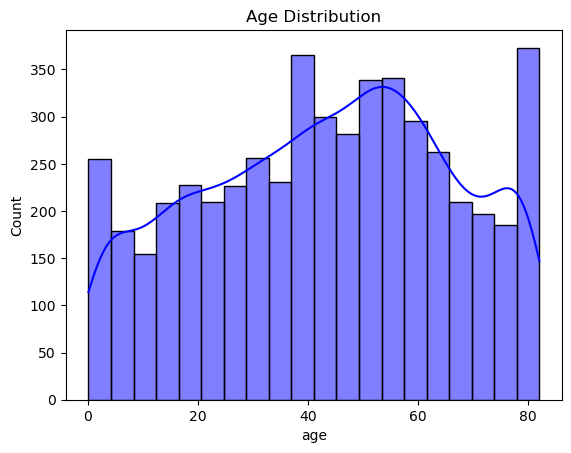

In [26]:
sns.histplot(df['age'],kde=True, color = 'blue')
plt.title('Age Distribution')
plt.show()

#### Observation:
- Most patients are middle-aged or elderly.
- Few very young patients

## Average Glucose Level

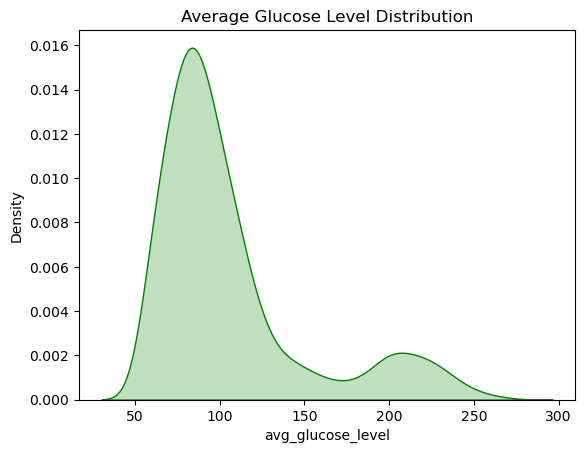

In [27]:
sns.kdeplot(x = 'avg_glucose_level',data = df,fill=True, color = 'green')
plt.title('Average Glucose Level Distribution')
plt.show()

#### Observation:
- Distribution is right-skewed
- Some individuals have very high glucose levels.

## BMI :

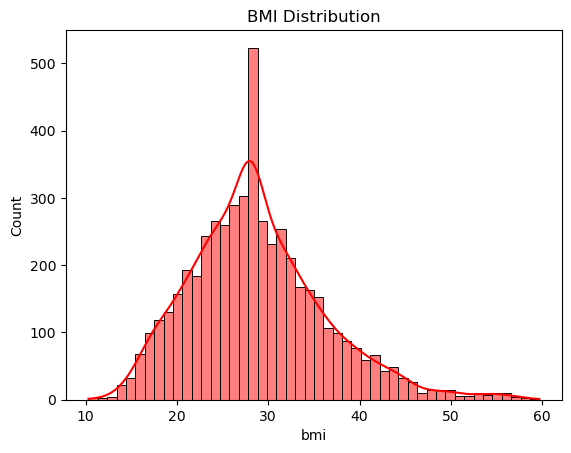

In [28]:
sns.histplot(df['bmi'],kde=True, color = 'red')
plt.title('BMI Distribution')
plt.show()

#### observation:
- Most BMI values lie between normal and overweight ranges.
- Some extreme BMI values exists

# Gender Distribution

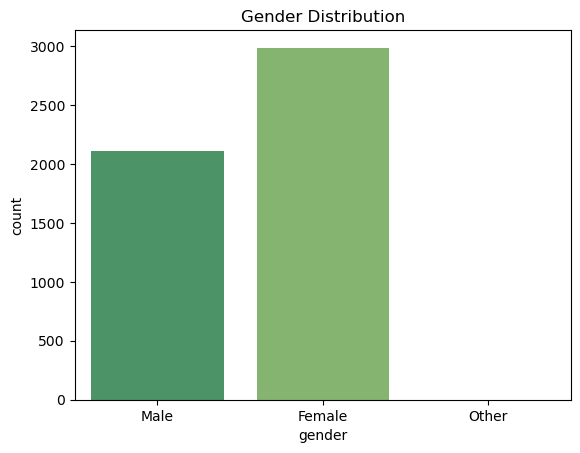

In [29]:
sns.countplot(x='gender',data = df, palette = 'summer')
plt.title('Gender Distribution')
plt.show()

#### Observation:
- Female and Male categories dominate.
- Other category has very few records.

# Smoking Status Distribution:

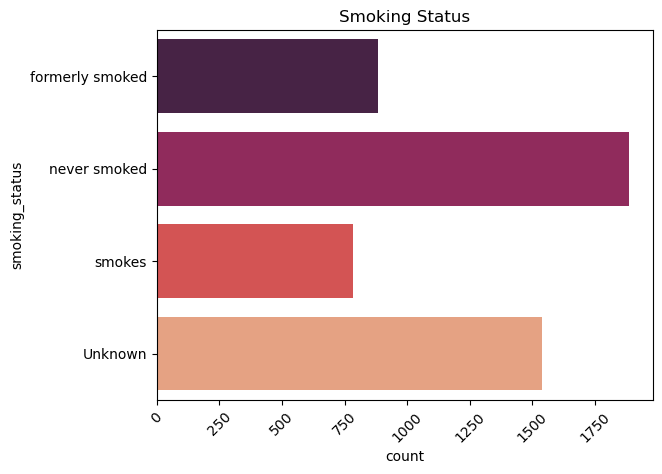

In [30]:
sns.countplot(y = 'smoking_status', data = df, palette = 'rocket')
plt.title('Smoking Status')
plt.xticks(rotation=45)
plt.show()

#### Observation:
- Never smoked category is the largest.
- Unknown category is also significant.

# Hypertension Distribution:

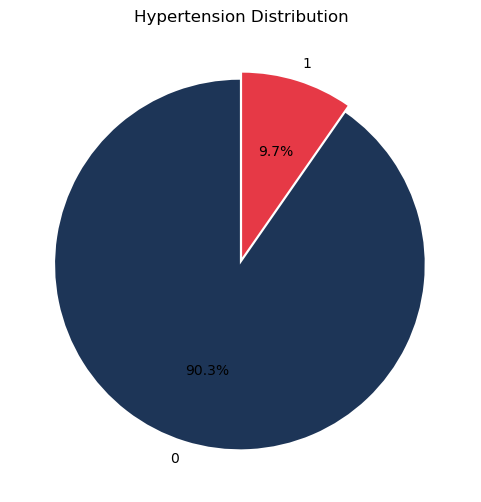

In [31]:
plt.figure(figsize=(6,6))
custom_colors = ['#1d3557', '#e63946']
df['hypertension'].value_counts().plot(kind = 'pie',autopct = '%1.1f%%',
                                      startangle=90, explode = [0.02]*df['hypertension'].nunique(),
                                     colors=custom_colors)
plt.title('Hypertension Distribution')
plt.ylabel("")
plt.show()

#### Observation:
- Most patients do not have hypertension

# Heart Disease Distribution

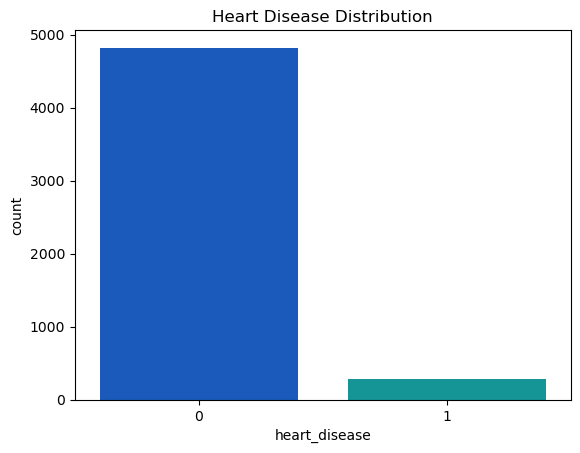

In [32]:
sns.countplot(x = 'heart_disease', data = df,palette = 'winter')
plt.title('Heart Disease Distribution')
plt.show()

#### Observation:
Majority of patients do not have heart disease.

# Stroke Distribution

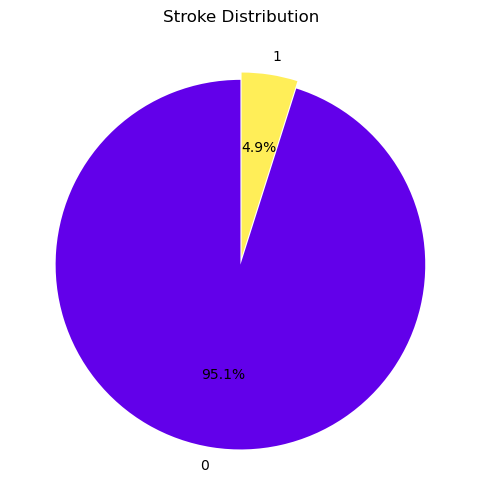

In [33]:
plt.figure(figsize=(6,6))
custom_colors = ['#6200ea', '#ffee58']
df['stroke'].value_counts().plot(kind = 'pie',autopct = '%1.1f%%',
                                      startangle=90, explode = [0.02]*df['stroke'].nunique(),
                                     colors=custom_colors)
plt.title('Stroke Distribution')
plt.ylabel("")
plt.show()

#### Observation:
- Stroke cases are much fewer than non-stroke cases.
- Indicates class imbalance.

# Bivariate Analysis

## Stroke vs Hypertension Distribution

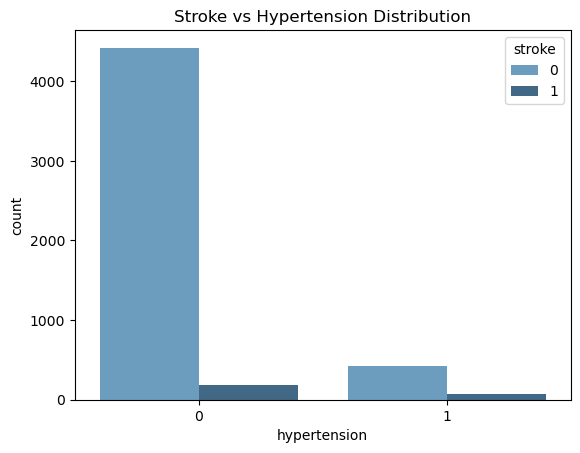

In [34]:
sns.countplot(x = 'hypertension', hue = 'stroke', data = df,palette = 'Blues_d')
plt.title('Stroke vs Hypertension Distribution')
plt.show()

#### Observation
- Stroke occurrence is higher among hypertensive patients.

## Stroke vs Heart Disease

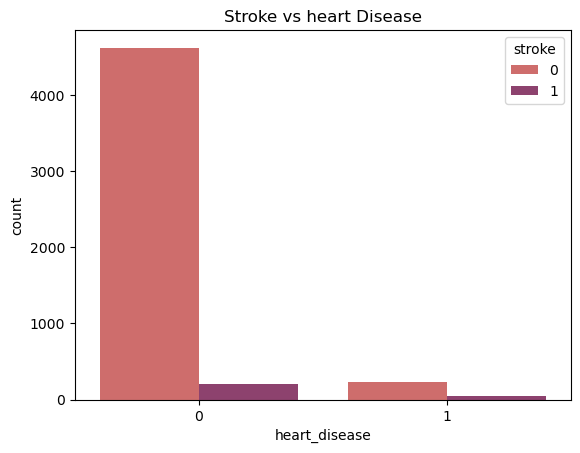

In [35]:
sns.countplot(x = 'heart_disease', hue = 'stroke', data=df,palette = 'flare')
plt.title('Stroke vs heart Disease')
plt.show()

#### Observation
- Patients with heart disease show higher stroke incidence.

## Age vs Stroke

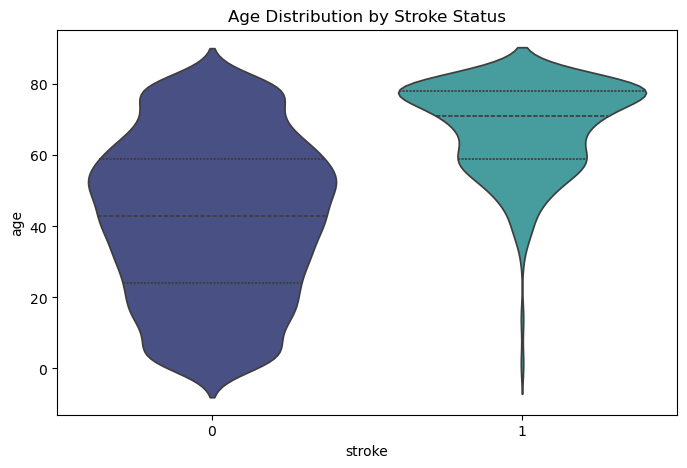

In [36]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='stroke', y='age', data=df, palette='mako', inner='quartile')
plt.title('Age Distribution by Stroke Status')
plt.show()

#### Observation
- Stroke patients tend to be older.

## BMI vs Stroke

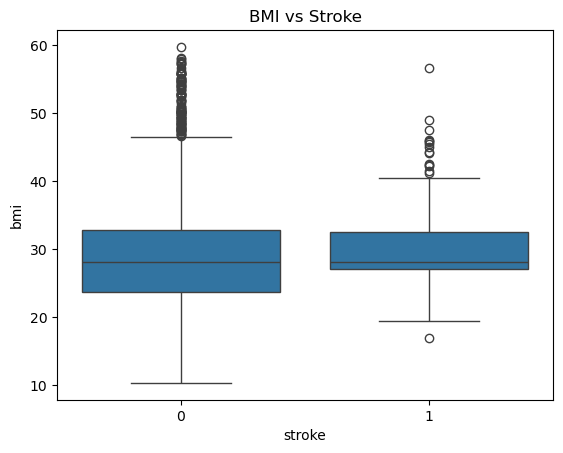

In [37]:
sns.boxplot(x = 'stroke', y = 'bmi' , data = df)
plt.title('BMI vs Stroke')
plt.show()

#### Observation
- Stroke patients generally have slightly higher BMI values.

## Average Glucose level vs Stroke

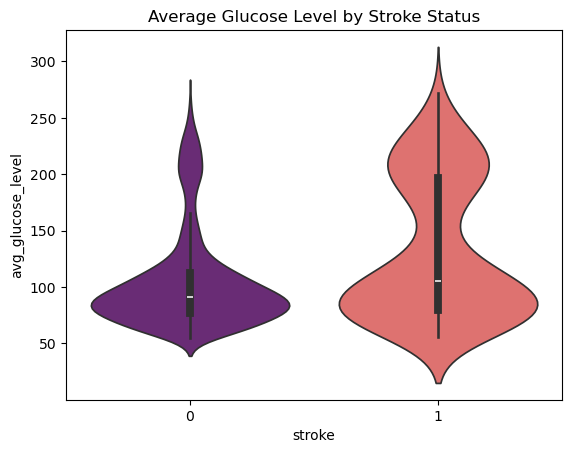

In [38]:
sns.violinplot(x='stroke', y='avg_glucose_level', data=df,palette = 'magma')
plt.title('Average Glucose Level by Stroke Status')
plt.show()

#### Observation :
- Stroke patients tend to have higher glucose levels.

# MultiVariate Analysis

## Correlation Heatmap

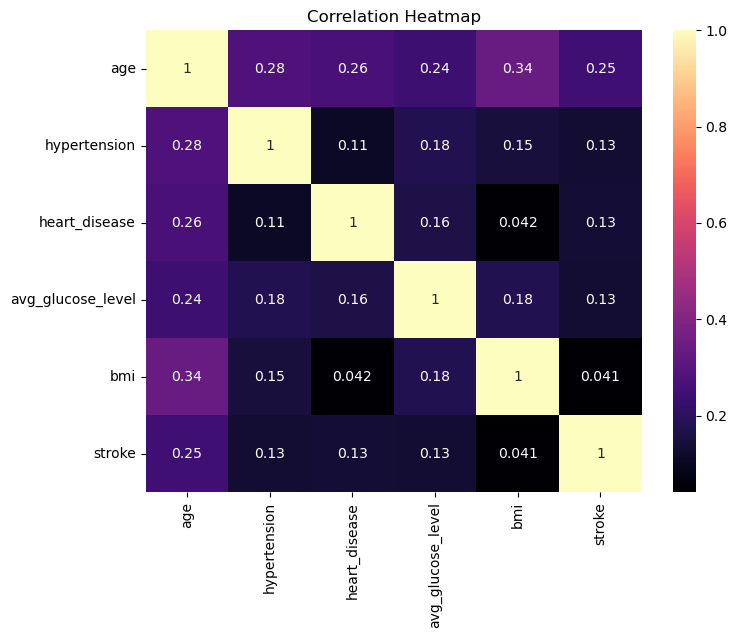

In [39]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='magma')
plt.title('Correlation Heatmap')
plt.show()

####  Observation :
- Age shows positive correlation with stroke.
- Hypertension and heart disease also show positive relationships.
- No very strong correlations among predictors.

## Age vs Average Glucose Level 

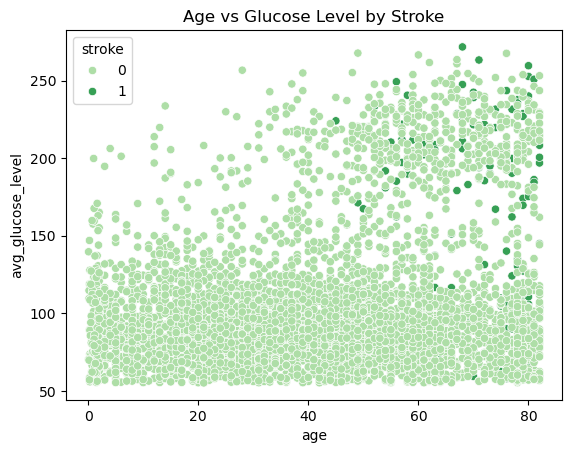

In [40]:
sns.scatterplot(
    x='age',
    y='avg_glucose_level',
    hue='stroke',
    data=df,palette = 'Greens'
)
plt.title('Age vs Glucose Level by Stroke')
plt.show()

#### Observation :
- Stroke cases are concentrated among older patients.
- High glucose levels combined with old age increase stroke occurrence

## Pairplot

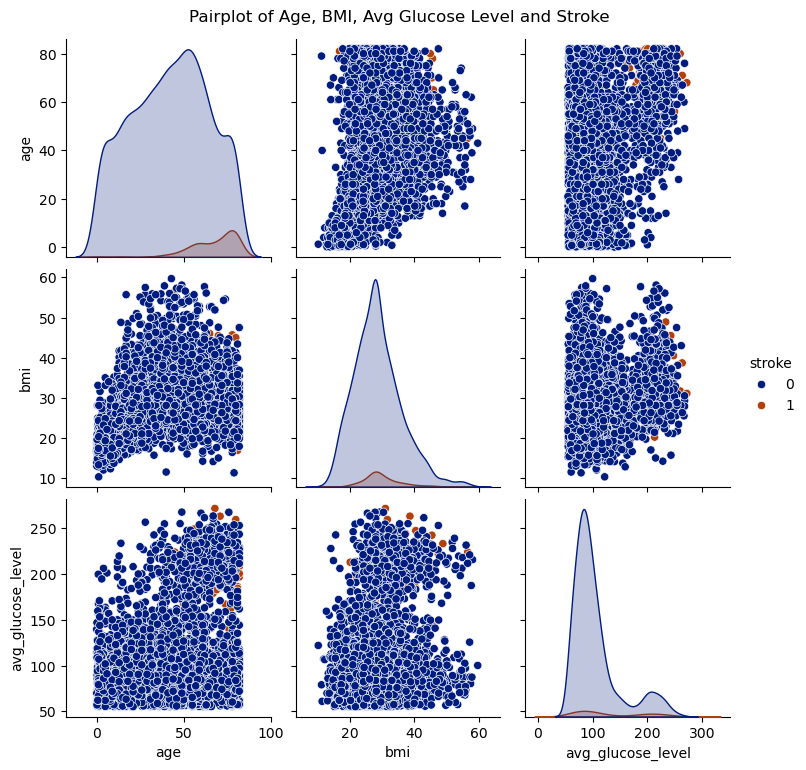

In [44]:
sns.pairplot(
    df,
    vars=['age', 'bmi', 'avg_glucose_level'],
    hue='stroke',
    palette = 'dark')
plt.suptitle("Pairplot of Age, BMI, Avg Glucose Level and Stroke",y=1.02)
plt.show()

#### Observation :
- Stroke cases are concentrated among older individuals.
- Higher average glucose levels are more common in stroke patients.
- BMI does not show a very strong separation between stroke and non-stroke groups.
- Age appears to have a stronger relationship with stroke than BMI.

# Pivot Table Analysis

## Stroke Case by Gender

In [42]:
pd.pivot_table(df,values = 'stroke',index = 'gender',aggfunc = 'sum')

,stroke
gender,
Female,141
Male,108
Other,0


#### Observation
- Shows total stroke cases among males and females.
- Helps identify which gender is more affected.

## Average BMI by Stroke Status

In [43]:
pd.pivot_table(df,values = 'bmi',index = 'stroke',aggfunc = 'mean')

,bmi
stroke,
0,28.689955
1,30.090361


#### Observation
- Shows whether stroke patients have higher BMI.